In [14]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss,f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Root directory containing data folders
root_dir = './Paderborn_PreCase1_Data'

# Class label structure
data_structure = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}

# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signals = {"vibration": 6, "current_1": 1, "current_2": 2}
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    field = next(k for k in mat if not k.startswith("__"))
    struct = mat[field]
    X_channels = struct.X
    Y_channels = struct.Y
    v = Y_channels[signals["vibration"]].Data.flatten().reshape(-1, 1)
    return pd.DataFrame(v, columns=["vibration"])

# Data extraction
all_data = {0: [], 1: [], 2: []}

for label, (category, folders) in data_structure.items():
    for folder in folders:
        folder_path = os.path.join(root_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found.")
            continue

        mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
        if not mat_files:
            print(f"No .mat files found in {folder_path}")
            continue

        filename = mat_files[0]
        file_path = os.path.join(folder_path, filename)
        try:
            df = extract_signals_df(file_path, signal="vibration")
            df = df.iloc[:sample_limit_per_label[label]].copy()
            df["label"] = label
            all_data[label].append(df)
            print(f"Loaded {file_path} with {len(df)} samples.")
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Combine all data
final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
final_df.rename(columns={"vibration": "signal"}, inplace=True)
print("\nCombined data shape:", final_df.shape)
print(final_df.head())

# Signal grouping
df_signals = final_df[["signal", "label"]].copy()
grouped_signals = [
    df_signals[df_signals['label'] == i]['signal'].values.astype(float)
    for i in sorted(df_signals['label'].unique())
]



# Datapoints per group
# print("\n Count of samples in each group")
for idx, signal_array in enumerate(grouped_signals):
    class_name = data_structure[idx][0]
    print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")


Loaded ./Paderborn_PreCase1_Data/K001/N15_M07_F04_K001_13.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K002/N09_M07_F10_K002_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K003/N09_M07_F10_K003_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K004/N09_M07_F10_K004_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K005/N09_M07_F10_K005_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/KA04/N09_M07_F10_KA04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA15/N09_M07_F10_KA15_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA16/N09_M07_F10_KA16_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA22/N09_M07_F10_KA22_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA30/N09_M07_F10_KA30_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI04/N09_M07_F10_KI04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI14/N09_M07_F10_KI14_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_D

In [15]:
# Save per-label CSVs
for label, dfs in all_data.items():
    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True)
        combined_df.rename(columns={"vibration": "signal"}, inplace=True)
        out_file = f"Label{label}_{data_structure[label][0]}.csv"
        combined_df.to_csv(out_file, index=False)
        print(f"Exported: {out_file} with shape {combined_df.shape}")
    else:
        print(f"No data to export for label {label}.")

Exported: Label0_Healthy.csv with shape (1280000, 2)
Exported: Label1_OR_Damage.csv with shape (25600, 2)
Exported: Label2_IR_Damage.csv with shape (25600, 2)


In [16]:
# Sampling configuration
interval_length = 320
samples_per_block = 1600

# Data preparation
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

def DataPreparation(DataList, interval_length, samples_per_block):
    for count, signal in enumerate(DataList):
        SplitData = Sampling(signal, interval_length, samples_per_block)
        segments = SplitData.shape[0]
        
        print(f"\nClass: {count} Fault Label: {data_structure[count][0]}")
        print(f"Segments: {segments} segments")
        print(f"Sample data (first 5 elements): {SplitData[0][:5] if segments > 0 else 'Empty'}")
        
        
        if SplitData.shape[0] == 0:
            continue
        y = np.zeros([len(SplitData), len(DataList)])
        y[:, count] = 1
        y1 = np.zeros([len(SplitData), 1])
        y1[:, 0] = count
        if count == 0:
            X = SplitData
            LabelPositional = y
            Label = y1
        else:
            X = np.append(X, SplitData, axis=0)
            LabelPositional = np.append(LabelPositional, y, axis=0)
            Label = np.append(Label, y1, axis=0)
    return X, LabelPositional, Label

# Run preparation
X_train, y_train_positional, y_train = DataPreparation(grouped_signals, interval_length, samples_per_block)




Class: 0 Fault Label: Healthy
Segments: 4407 segments
Sample data (first 5 elements): [-0.10070801  1.22375488 -0.18615723 -0.22277832 -0.1373291 ]

Class: 1 Fault Label: OR_Damage
Segments: 81 segments
Sample data (first 5 elements): [ 0.18005371  0.08850098 -0.05187988 -0.16784668 -0.24414062]

Class: 2 Fault Label: IR_Damage
Segments: 81 segments
Sample data (first 5 elements): [-0.0793457   0.18005371  0.3692627   0.35095215  0.61645508]


In [17]:
# Split into training and test sets (80% train, 20% test)
X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
    X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

input_shape = (40, 40, 1)   # Reshaped input for CNN 2D
print(f"\nInput Shape: {input_shape}")

# Convert one-hot labels to class indices
y_train_labels = np.argmax(y_train_positional_split, axis=1)
y_test_labels = np.argmax(y_test_positional_split, axis=1)

# Count samples per class
unique_train, counts_train = np.unique(y_train_labels, return_counts=True)
unique_test, counts_test = np.unique(y_test_labels, return_counts=True)

print("\nClass distribution in training set:")
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nClass distribution in test set:")
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")

print("Train label distribution:", np.bincount(y_train_labels.flatten().astype(int)))
print("Test label distribution:", np.bincount(y_test_labels.flatten().astype(int)))

# Reshape data to 2D for CNN input
X_2D_train = X_train_split.reshape([-1, 40, 40, 1])
X_2D_test = X_test_split.reshape([-1, 40, 40, 1])

print(f"\nX_2D_train shape: {X_2D_train.shape}")
print(f"Y_train shape: {y_train_positional_split.shape}")
print(f"X_2D_test shape: {X_2D_test.shape}")
print(f"Y_test shape: {y_test_positional_split.shape}")



Input Shape: (40, 40, 1)

Class distribution in training set:
Class 0: 3525 samples
Class 1: 65 samples
Class 2: 65 samples

Class distribution in test set:
Class 0: 882 samples
Class 1: 16 samples
Class 2: 16 samples
Train label distribution: [3525   65   65]
Test label distribution: [882  16  16]

X_2D_train shape: (3655, 40, 40, 1)
Y_train shape: (3655, 3)
X_2D_test shape: (914, 40, 40, 1)
Y_test shape: (914, 3)


In [18]:
class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()
        self.model.summary()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # layers.Flatten(),
            # layers.Dense(100,activation='relu'),
            # layers.Dense(50,activation='relu'),
            # layers.Dense(3, activation='softmax')

            layers.GlobalAveragePooling2D(),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(3, activation='softmax')

            # Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            # Dense(128, activation='relu'),  # Accepts 3200 units
            # Dropout(0.5),
            # Dense(10, activation='softmax')  # 10 classes

            
        ])

        # Optimizer with a slightly higher learning rate
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss=tf.keras.losses.CategoricalCrossentropy(),
                      metrics=['accuracy'])
        return model

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

 Trainable params: 106,083 (414.39 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9918 - val_loss: 0.0223
Epoch 10/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9992 - loss: 0.0031
Epoch 10: val_accuracy did not improve from 0.99179
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9992 - loss: 0.0032 - val_accuracy: 0.9863 - val_loss: 0.1171
Epoch 11/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9998 - loss: 0.0015
Epoch 11: val_accuracy did not improve from 0.99179
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 0.9904 - val_loss: 0.0368
Epoch 12/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9998 - loss: 0.0011
Epoch 12: val_accuracy did not improve from 0.99179
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9904 - val_loss: 0.0398
Epoch 13/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9991 - loss: 0.0039
Epoch 13: val_accuracy did not i

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 1.0000 - loss: 6.6475e-04 - val_accuracy: 0.9945 - val_loss: 0.0157
Epoch 24/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 3.6389e-04
Epoch 24: val_accuracy improved from 0.99453 to 0.99590, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_1.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 1.0000 - loss: 3.6281e-04 - val_accuracy: 0.9959 - val_loss: 0.0099
Epoch 25/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 6.3910e-04
Epoch 25: val_accuracy did not improve from 0.99590
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 1.0000 - loss: 6.3007e-04 - val_accuracy: 0.9959 - val_loss: 0.0109
Epoch 26/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 1.1145e-04
Epoch 26: val_accuracy did not improve from 0.99590
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 1.0000 - loss: 1.1131e-04 - val_accuracy: 0.9945 - val_loss: 0.0150
Epoch 27/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 4.4055e-05
Epoch 27: val_accuracy did not improve from 0.99590
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 1.0000 - loss: 4.4537e-05 - val_accuracy: 0.9959 - val_loss: 0.0107
Epoch 28/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 6.6652e-05


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 1.0000 - loss: 2.8473e-05 - val_accuracy: 0.9973 - val_loss: 0.0062
Epoch 41/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 2.8411e-05
Epoch 41: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 1.0000 - loss: 2.8179e-05 - val_accuracy: 0.9973 - val_loss: 0.0054
Epoch 42/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 8.5927e-06
Epoch 42: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 1.0000 - loss: 8.6311e-06 - val_accuracy: 0.9973 - val_loss: 0.0067
Epoch 43/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 2.0623e-05
Epoch 43: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 1.0000 - loss: 2.0628e-05 - val_accuracy: 0.9973 - val_loss: 0.0071
Epoch 44/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 2.9555e-05


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 1.0000 - loss: 2.3651e-04 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 72/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 3.8639e-04
Epoch 72: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 1.0000 - loss: 3.8218e-04 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 73/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 1.4273e-04
Epoch 73: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 1.4274e-04 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 74/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 6.4766e-05
Epoch 74: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 1.0000 - loss: 6.4608e-05 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 75/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 1.1987e-04


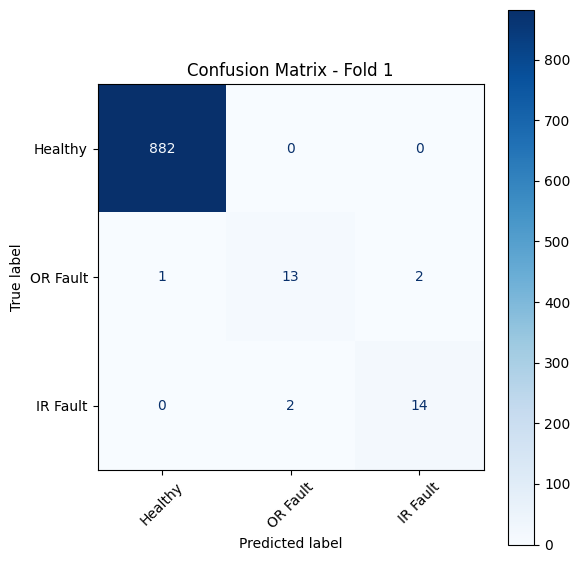

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/confusion_matrices/confusion_matrix_fold_1.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9957 - loss: 0.0091 - val_accuracy: 0.9918 - val_loss: 0.0170
Epoch 8/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9972 - loss: 0.0054
Epoch 8: val_accuracy did not improve from 0.99179
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9973 - loss: 0.0053 - val_accuracy: 0.9918 - val_loss: 0.0120
Epoch 9/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9989 - loss: 0.0041
Epoch 9: val_accuracy improved from 0.99179 to 0.99453, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_2.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9989 - loss: 0.0040 - val_accuracy: 0.9945 - val_loss: 0.0357
Epoch 10/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9988 - loss: 0.0033
Epoch 10: val_accuracy did not improve from 0.99453
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9988 - loss: 0.0033 - val_accuracy: 0.9808 - val_loss: 0.0399
Epoch 11/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9992 - loss: 0.0036
Epoch 11: val_accuracy did not improve from 0.99453
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9991 - loss: 0.0037 - val_accuracy: 0.9904 - val_loss: 0.1062
Epoch 12/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9928 - loss: 0.0257
Epoch 12: val_accuracy improved from 0.99453 to 0.99590, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_2.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9929 - loss: 0.0253 - val_accuracy: 0.9959 - val_loss: 0.0094
Epoch 13/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9979 - loss: 0.0041
Epoch 13: val_accuracy did not improve from 0.99590
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9980 - loss: 0.0041 - val_accuracy: 0.9945 - val_loss: 0.0098
Epoch 14/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9994 - loss: 0.0032
Epoch 14: val_accuracy did not improve from 0.99590
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.8906 - val_loss: 0.2412
Epoch 15/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 15: val_accuracy did not improve from 0.99590
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9918 - val_loss: 0.0149
Epoch 16/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9999 - loss: 7.5035e-04
Epoch 16: val_accuracy did n

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9973 - val_loss: 0.0106
Epoch 22/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9987 - loss: 0.0018
Epoch 22: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9988 - loss: 0.0018 - val_accuracy: 0.9959 - val_loss: 0.0193
Epoch 23/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 1.3682e-04
Epoch 23: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 1.3712e-04 - val_accuracy: 0.9959 - val_loss: 0.0141
Epoch 24/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 7.1949e-05
Epoch 24: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 7.2168e-05 - val_accuracy: 0.9959 - val_loss: 0.0140
Epoch 25/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 1.4615e-04
Epoch 25: va

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 1.0000 - loss: 1.3230e-05 - val_accuracy: 0.9986 - val_loss: 0.0129
Epoch 55/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 5.4347e-06
Epoch 55: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 1.0000 - loss: 5.4527e-06 - val_accuracy: 0.9973 - val_loss: 0.0135
Epoch 56/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 7.4108e-06
Epoch 56: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 1.0000 - loss: 7.3142e-06 - val_accuracy: 0.9959 - val_loss: 0.0142
Epoch 57/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 4.7557e-06
Epoch 57: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 1.0000 - loss: 4.7636e-06 - val_accuracy: 0.9959 - val_loss: 0.0144
Epoch 58/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 9.7112e-06


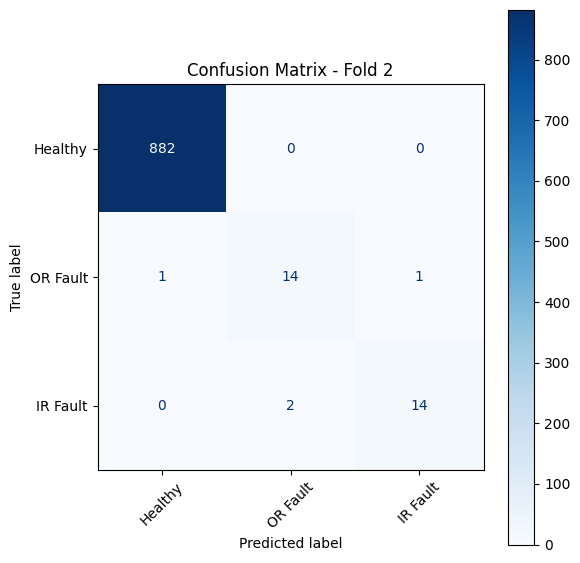

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/confusion_matrices/confusion_matrix_fold_2.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9987 - loss: 0.0056 - val_accuracy: 0.9877 - val_loss: 0.0292
Epoch 8/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9942 - loss: 0.0121
Epoch 8: val_accuracy did not improve from 0.98769
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9942 - loss: 0.0120 - val_accuracy: 0.9850 - val_loss: 0.0324
Epoch 9/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9889 - loss: 0.0265
Epoch 9: val_accuracy did not improve from 0.98769
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9889 - loss: 0.0264 - val_accuracy: 0.9808 - val_loss: 0.0525
Epoch 10/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9949 - loss: 0.0148
Epoch 10: val_accuracy improved from 0.98769 to 0.99042, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_3.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9949 - loss: 0.0147 - val_accuracy: 0.9904 - val_loss: 0.0158
Epoch 11/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9976 - loss: 0.0044
Epoch 11: val_accuracy improved from 0.99042 to 0.99316, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_3.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9976 - loss: 0.0044 - val_accuracy: 0.9932 - val_loss: 0.0125
Epoch 12/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0011
Epoch 12: val_accuracy improved from 0.99316 to 0.99863, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_3.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9986 - val_loss: 0.0027
Epoch 13/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 4.5953e-04
Epoch 13: val_accuracy improved from 0.99863 to 1.00000, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_3.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 1.0000 - loss: 4.5606e-04 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 14/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 5.1430e-04
Epoch 14: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 1.0000 - loss: 5.0938e-04 - val_accuracy: 0.9986 - val_loss: 0.0026
Epoch 15/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 2.5925e-04
Epoch 15: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 2.5661e-04 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 16/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 3.4943e-04
Epoch 16: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 3.4715e-04 - val_accuracy: 0.9973 - val_loss: 0.0046
Epoch 17/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 2.0060e-04


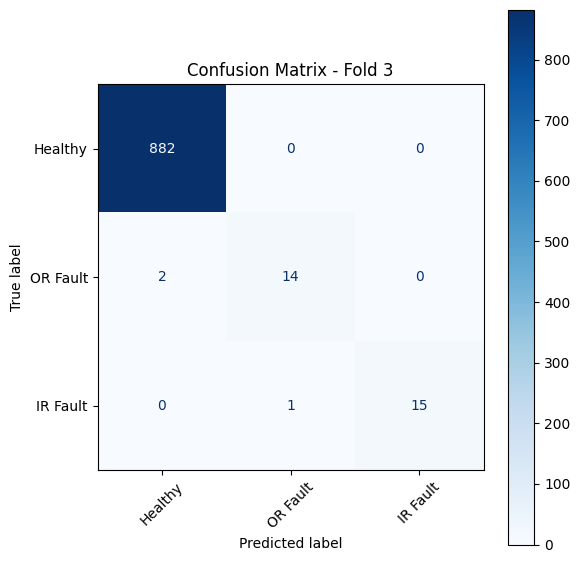

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/confusion_matrices/confusion_matrix_fold_3.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

Epoch 1/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8736 - loss: 0.3419
Epoch 1: val_accuracy improved from -inf to 0.73598, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_4.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8772 - loss: 0.3327 - val_accuracy: 0.7360 - val_loss: 0.7230
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9857 - loss: 0.0396
Epoch 2: val_accuracy did not improve from 0.73598
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9857 - loss: 0.0395 - val_accuracy: 0.0123 - val_loss: 2.1257
Epoch 3/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9937 - loss: 0.0236
Epoch 3: val_accuracy did not improve from 0.73598
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9937 - loss: 0.0236 - val_accuracy: 0.5390 - val_loss: 2.0261
Epoch 4/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9942 - loss: 0.0162
Epoch 4: val_accuracy did not improve from 0.73598
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9941 - loss: 0.0164 - val_accuracy: 0.6060 - val_loss: 2.3971
Epoch 5/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9853 - loss: 0.0407
Epoch 5: val_accuracy did not improve f

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9961 - loss: 0.0150 - val_accuracy: 0.9918 - val_loss: 0.0207
Epoch 7/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9967 - loss: 0.0081
Epoch 7: val_accuracy did not improve from 0.99179
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9967 - loss: 0.0080 - val_accuracy: 0.9795 - val_loss: 0.0475
Epoch 8/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9957 - loss: 0.0125
Epoch 8: val_accuracy improved from 0.99179 to 0.99590, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_4.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9957 - loss: 0.0124 - val_accuracy: 0.9959 - val_loss: 0.0105
Epoch 9/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9994 - loss: 0.0035
Epoch 9: val_accuracy improved from 0.99590 to 0.99863, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_4.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9994 - loss: 0.0035 - val_accuracy: 0.9986 - val_loss: 0.0109
Epoch 10/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0013
Epoch 10: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9973 - val_loss: 0.0102
Epoch 11/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 8.5464e-04
Epoch 11: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 1.0000 - loss: 8.5632e-04 - val_accuracy: 0.9959 - val_loss: 0.0080
Epoch 12/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9996 - loss: 0.0021
Epoch 12: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9822 - val_loss: 0.0742
Epoch 13/200
89/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9964 - loss: 0.0115
Epoch 13: val_accuracy d

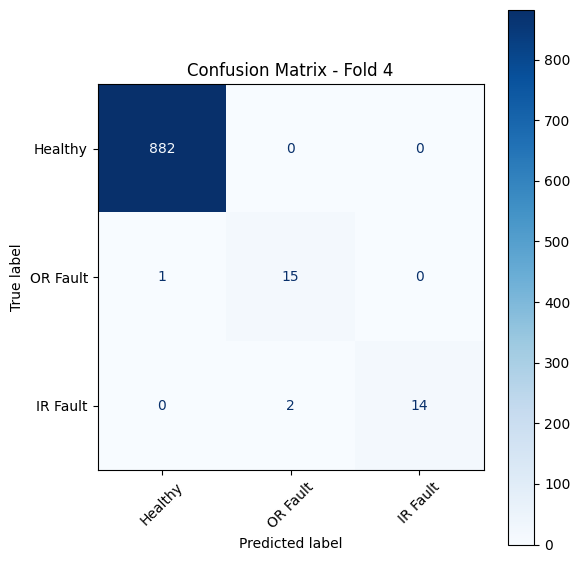

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/confusion_matrices/confusion_matrix_fold_4.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 40, 40, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 40, 40, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 5, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9953 - loss: 0.0114 - val_accuracy: 0.9891 - val_loss: 0.0325
Epoch 8/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9981 - loss: 0.0054
Epoch 8: val_accuracy did not improve from 0.98906
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9980 - loss: 0.0055 - val_accuracy: 0.9412 - val_loss: 0.1634
Epoch 9/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9910 - loss: 0.0264
Epoch 9: val_accuracy improved from 0.98906 to 0.99590, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_5.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9911 - loss: 0.0262 - val_accuracy: 0.9959 - val_loss: 0.0155
Epoch 10/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9996 - loss: 0.0026
Epoch 10: val_accuracy improved from 0.99590 to 0.99726, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_5.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9996 - loss: 0.0026 - val_accuracy: 0.9973 - val_loss: 0.0081
Epoch 11/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9994 - loss: 0.0020
Epoch 11: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9994 - loss: 0.0020 - val_accuracy: 0.9959 - val_loss: 0.0058
Epoch 12/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9985 - loss: 0.0047
Epoch 12: val_accuracy did not improve from 0.99726
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9985 - loss: 0.0047 - val_accuracy: 0.9904 - val_loss: 0.0295
Epoch 13/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9989 - loss: 0.0077
Epoch 13: val_accuracy improved from 0.99726 to 0.99863, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_5.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9989 - loss: 0.0076 - val_accuracy: 0.9986 - val_loss: 0.0029
Epoch 14/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9997 - loss: 9.8986e-04
Epoch 14: val_accuracy improved from 0.99863 to 1.00000, saving model to Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/best_model_fold_5.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9997 - loss: 9.9420e-04 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 15/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 2.8318e-04
Epoch 15: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 1.0000 - loss: 2.8165e-04 - val_accuracy: 0.9986 - val_loss: 0.0030
Epoch 16/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 8.3272e-05
Epoch 16: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 1.0000 - loss: 8.3822e-05 - val_accuracy: 0.9986 - val_loss: 0.0037
Epoch 17/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 1.2198e-04
Epoch 17: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 1.0000 - loss: 1.2332e-04 - val_accuracy: 0.9986 - val_loss: 0.0025
Epoch 18/200
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 2.5824e-04


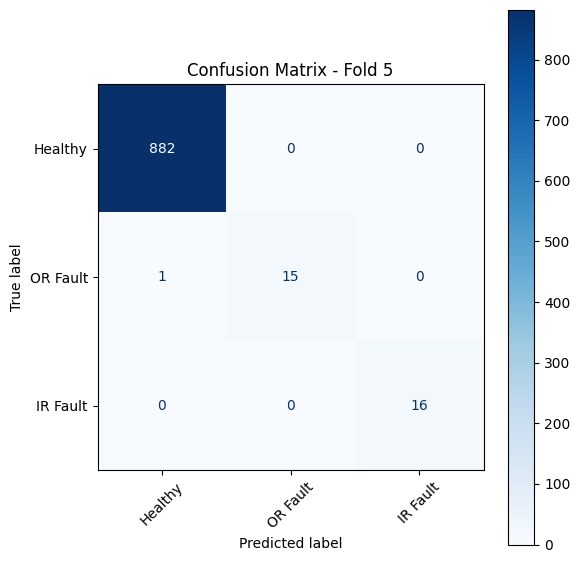

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/confusion_matrices/confusion_matrix_fold_5.png
Total Computation Time: 1171.17 seconds (19.52 minutes)


In [21]:
# Training with k-fold validation
kSplits = 5
accuracy_2D = []
precision_2D = []
recall_2D = []
f1_2D = []
log_loss_2D = []
balanced_accuracy_2D = []
precision_2D_macro = []
recall_2D_macro = []
f1_2D_macro = []
accuracy_2D_test = []
precision_2D_test = []
recall_2D_test = []
log_loss_2D_test = []
f1_2D_test = []
precision_2D_test_macro = []
recall_2D_test_macro = []
f1_2D_test_macro = []
balanced_accuracy_2D_test = []
# accuracy_val = []

foldername = "Paderborn_results/Paderborn-imbalance-2D-RandomTrain-test/"

condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
start_time = time.time()
y_labels = np.argmax(y_train_positional_split, axis=1)

kfold = StratifiedKFold(n_splits=kSplits, random_state=32, shuffle=True)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_2D_train, y_labels)):

    Classification_2D = CNN_2D()

    checkpoint_filepath = os.path.join(foldername, f"best_model_fold_{fold+1}.h5")
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )

    Classification_2D.model.fit(X_2D_train[train_idx], y_train_positional_split[train_idx],
                                validation_data=(X_2D_train[test_idx], y_train_positional_split[test_idx]),
                                epochs=200, callbacks=[early_stopping, checkpoint], verbose=1)

    print(f"Best model for Fold {fold+1} saved to: {checkpoint_filepath}")

    # Train set metrics
    y_pred_proba_train = Classification_2D.model.predict(X_2D_train)
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(y_train_positional_split, axis=1)

    accuracy_2D.append(accuracy_score(y_true_train, y_pred_train))
    precision_2D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_2D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_2D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_2D.append(log_loss(y_true_train, y_pred_proba_train))
    balanced_accuracy_2D.append(balanced_accuracy_score(y_true_train, y_pred_train))
    precision_2D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_2D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_2D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))

    # Test set metrics
    y_pred_proba_test = Classification_2D.model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(y_test_positional_split, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()

    # Save confusion matrix
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    # accuracy_val.append(accuracy_score(X_2D_train[test_idx], y_train_positional_split[test_idx]))
    accuracy_2D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_2D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_2D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_2D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_2D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_2D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_2D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_2D_test.append(log_loss(y_true_test, y_pred_proba_test))
    balanced_accuracy_2D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Computation Time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [22]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_2D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_2D_test) * 100
CNN_2D_train_precision = np.mean(precision_2D) * 100
CNN_2D_test_precision = np.mean(precision_2D_test) * 100
CNN_2D_train_recall = np.mean(recall_2D) * 100
CNN_2D_test_recall = np.mean(recall_2D_test) * 100
CNN_2D_train_f1 = np.mean(f1_2D) * 100
CNN_2D_test_f1 = np.mean(f1_2D_test) * 100
CNN_2D_train_precision_macro = np.mean(precision_2D_macro) * 100
CNN_2D_train_recall_macro = np.mean(recall_2D_macro) * 100
CNN_2D_train_f1_macro = np.mean(f1_2D_macro) * 100
CNN_2D_test_precision_macro = np.mean(precision_2D_test_macro) * 100
CNN_2D_test_recall_macro = np.mean(recall_2D_test_macro) * 100
CNN_2D_test_f1_macro = np.mean(f1_2D_test_macro) * 100
CNN_2D_train_log_loss = np.mean(log_loss_2D)
CNN_2D_test_log_loss = np.mean(log_loss_2D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_2D) * 100
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_2D_test) * 100
# CNN_2D_val_accuracy = np.mean(accuracy_val) * 100

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1: {CNN_2D_train_f1:.2f}%")
print(f"Test F1: {CNN_2D_test_f1:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

print(f"Train Precision (Macro): {CNN_2D_train_precision_macro:.2f}%")
print(f"Train Recall (Macro): {CNN_2D_train_recall_macro:.2f}%")
print(f"Train F1 Score (Macro): {CNN_2D_train_f1_macro:.2f}%")

print(f"Test Precision (Macro): {CNN_2D_test_precision_macro:.2f}%")
print(f"Test Recall (Macro): {CNN_2D_test_recall_macro:.2f}%")
print(f"Test F1 Score (Macro): {CNN_2D_test_f1_macro:.2f}%")

# print(f"CNN_2D_val_accuracy: {CNN_2D_val_accuracy:.2f}%")


Train Accuracy: 99.99%
Test Accuracy: 99.65%
Train Precision: 99.99%
Test Precision: 99.65%
Train Recall: 99.99%
Test Recall: 99.65%
Train F1: 99.99%
Test F1: 99.64%
Train Log Loss: 0.0016
Test Log Loss: 0.0171
Train Balanced Accuracy: 99.79%
Test Balanced Accuracy: 93.33%
Train Precision (Macro): 99.80%
Train Recall (Macro): 99.79%
Train F1 Score (Macro): 99.79%
Test Precision (Macro): 95.73%
Test Recall (Macro): 93.33%
Test F1 Score (Macro): 94.46%


In [ ]:
# Confusion Matrix Calculation
def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.model.predict(X)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y, axis=1)
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 2D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_train, y_train_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_test, y_test_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_2D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 2D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()


In [1]:
# Create DataFrame from per-fold metrics
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, kSplits + 1),
    
    'Train Accuracy (%)': np.array(accuracy_1D) * 100,
    'Test Accuracy (%)': np.array(accuracy_1D_test) * 100,

    'Train Precision (%)': np.array(precision_1D) * 100,
    'Test Precision (%)': np.array(precision_1D_test) * 100,

    'Train Recall (%)': np.array(recall_1D) * 100,
    'Test Recall (%)': np.array(recall_1D_test) * 100,

    'Train F1-score (%)': np.array(f1_1D) * 100,
    'Test F1-score (%)': np.array(f1_1D_test) * 100,

    'Train Precision-Macro (%)': np.array(precision_1D_macro) * 100,
    'Test Precision-Macro (%)': np.array(precision_1D_test_macro) * 100,

    'Train Recall-Macro (%)': np.array(recall_1D_macro) * 100,
    'Test Recall-Macro (%)': np.array(recall_1D_test_macro) * 100,

    'Train F1-score (%)': np.array(f1_1D_macro) * 100,
    'Test F1-score (%)': np.array(f1_1D_test_macro) * 100,

    'Train Log Loss': log_loss_1D,
    'Test Log Loss': log_loss_1D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_1D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_1D_test) * 100,
})

metrics_df

NameError: name 'pd' is not defined